# Probabilistic programming

In [9]:
#import sys
#!{sys.executable} -m pip install pymc

## Non-Markovian methods: Grid computing

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm

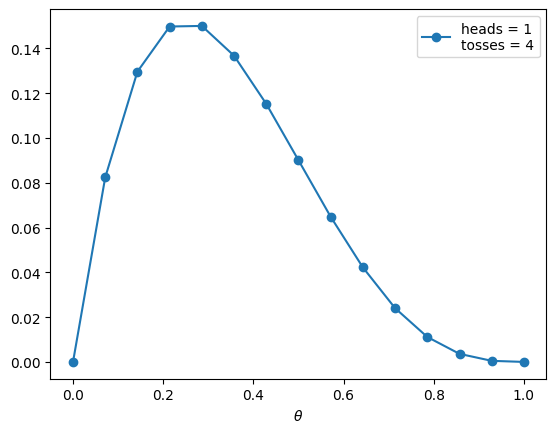

In [7]:
def posterior_grid(grid_points=100, heads=6, tosses=9):
    grid = np.linspace(0, 1, grid_points)
    prior = np.repeat(5, grid_points) # Uniform prior: assigns equal weight (constant value) to all values of theta
    likelihood = stats.binom.pmf(heads, tosses, grid)
    unstd_posterior = likelihood * prior
    posterior = unstd_posterior / unstd_posterior.sum()
    return grid, posterior

points = 15
h, n = 1, 4

grid, posterior = posterior_grid(points, h, n)

plt.plot(grid, posterior, 'o-', label=f'heads = {h}\ntosses = {n}')
plt.xlabel(r'$\theta$')
plt.legend(loc=0)
plt.show()

With 1 head and 3 tails (4 tosses in total), the posterior distribution is concentrated toward smaller values of θ, meaning the probability of heads is likely low. The posterior reaches its highest point near θ≈0.25, which is exactly the observed sample proportion 1/4. This means that, after combining the data with a uniform prior, the value θ≈0.25 is the most supported estimate of the coin’s bias. However, the posterior is not concentrated at a single point; it is spread over a range of values, indicating remaining uncertainty about the true value of θ.

## Monte Carlo

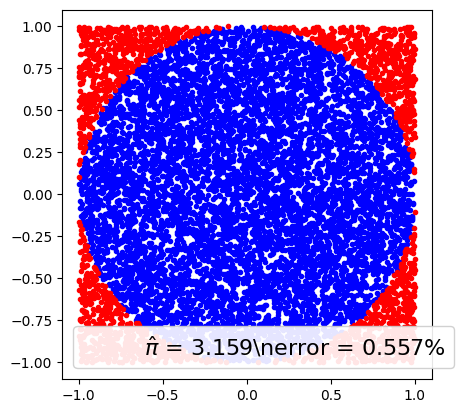

In [2]:
N = 10000
x, y = np.random.uniform(-1, 1, size=(2, N))
inside = (x**2 + y**2)  <= 1
pi = inside.sum()*4/N
error = abs((pi - np.pi)/pi)* 100
outside = np.invert(inside)
plt.plot(x[inside], y[inside], 'b.')
plt.plot(x[outside], y[outside], 'r.')
plt.plot(0, 0, 
         label=r'$\hat \pi$ = {:4.3f}\nerror = {:4.3f}%'.format(pi, error), 
         alpha=0)
plt.axis('square')
plt.legend(frameon=True, framealpha=0.9, fontsize=16);

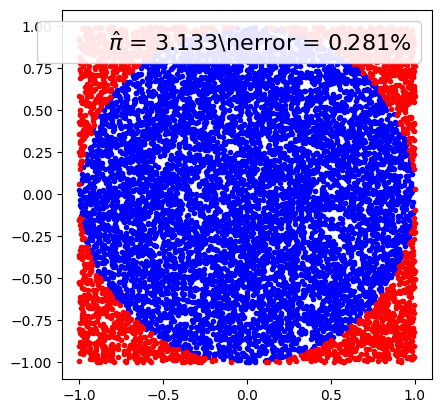

In [9]:
N = 10000
x, y = np.random.uniform(-1, 1, size=(2, N))
inside = (x**2 + y**2)  <= 1
pi = inside.sum()*4/N
error = abs((pi - np.pi)/pi)* 100
outside = np.invert(inside)
plt.plot(x[inside], y[inside], 'b.')
plt.plot(x[outside], y[outside], 'r.')
plt.plot(0, 0, 
         label=r'$\hat \pi$ = {:4.3f}\nerror = {:4.3f}%'.format(pi, error), 
         alpha=0)
plt.axis('square')
plt.legend(frameon=True, framealpha=0.9, fontsize=16);

## Metropolis-Hastings

In [10]:
def metropolis(func, steps=10000):
    """A very simple Metropolis implementation"""
    samples = np.zeros(steps)
    old_x = func.mean()
    old_prob = func.pdf(old_x)
    for i in range(steps):
        new_x = old_x + np.random.normal(0, 0.5)
        new_prob = func.pdf(new_x)
        acceptance = new_prob/old_prob
        if acceptance >= np.random.random():
            samples[i] = new_x
            old_x = new_x
            old_prob = new_prob
        else:
            samples[i] = old_x
    return samples

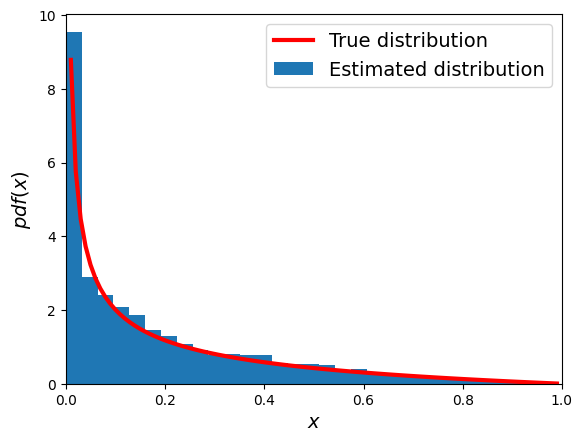

In [13]:
func = stats.beta(0.4, 2)
samples = metropolis(func=func)

x = np.linspace(0.01, .99, 100)
y = func.pdf(x)

plt.xlim(0, 1)
plt.plot(x, y, 'r-', lw=3, label='True distribution')
plt.hist(samples, bins=30, density=True, label='Estimated distribution')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$pdf(x)$', fontsize=14)
plt.legend(fontsize=14)
plt.show()

## Coin-flipping, the computational approach

In [11]:
np.random.seed(123)
n_experiments = 4
theta_real = 0.35
data = stats.bernoulli.rvs(p=theta_real, size=n_experiments)
print(data)

[1 0 0 0]


# Case 1: Single chain + burn-in + traceplot

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.
C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\arviz\plots\backends\matplotlib\traceplot.py:218: UserWarning: A valid var_name should be provided, found {'t'} expected from {'theta'}
  warnings.warn(


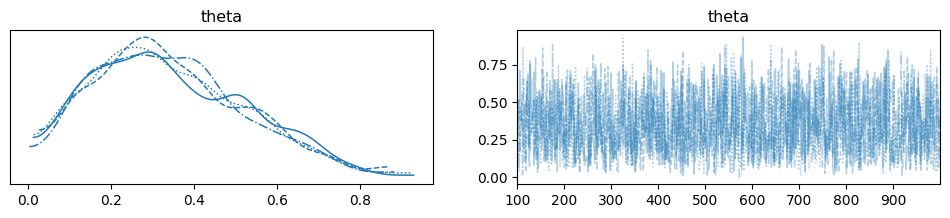

In [25]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Data
np.random.seed(123)
theta_real = 0.35
data = stats.bernoulli.rvs(p=theta_real, size=4)

# Model
with pm.Model() as model:
    theta = pm.Beta('theta', 1, 1)
    y = pm.Bernoulli('y', p=theta, observed=data)

    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

# Burn-in (optional demonstration)
burnin = 100
chain = trace.sel(draw=slice(burnin, None))

# Traceplot
az.plot_trace(chain, var_names=["theta"], lines={"theta": theta_real})
plt.show()

## Case 2: Multiple chains (convergence check)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.
C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\arviz\plots\backends\matplotlib\traceplot.py:218: UserWarning: A valid var_name should be provided, found {'t'} expected from {'theta'}
  warnings.warn(


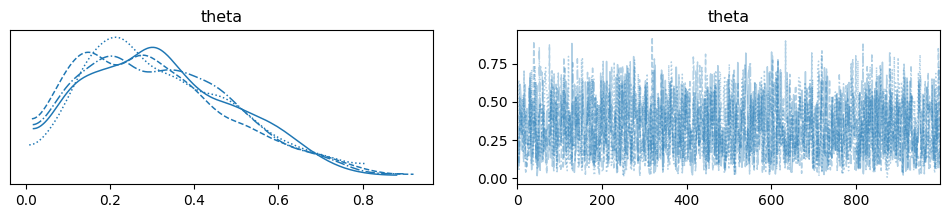

In [30]:
with pm.Model() as model:
    theta = pm.Beta('theta', 1, 1)
    y = pm.Bernoulli('y', p=theta, observed=data)

    multi_trace = pm.sample(
        1000,
        tune=1000,
        chains=4,
        cores=4,
        return_inferencedata=True
    )

# Traceplot across multiple chains
az.plot_trace(multi_trace, var_names=["theta"], lines={"theta": theta_real})
plt.show()

In [32]:
import arviz as az

az.rhat(multi_trace)

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    theta    float64 8B 1.003
Attributes:
    created_at:                 2026-04-09T08:40:02.108149+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              43.74186086654663
    tuning_steps:               1000